# Assignment 2

Before you start, make a branch for this assignment from an up-to-date `main`:

```bash
git switch main
git pull upstream main
git switch -c assignment-02

## 1. NumPy Arrays

- Create an array with `np.arange()` and `.reshape()` it into a 2-d array
- Print its `ndim`, `shape`, and `dtype`
- Compute its `.sum()` with `axis=0` and with `axis=1`. In a Markdown cell, explain the difference between the two results.
- Multiply your 2-d array by a 1-d array to demonstrate broadcasting

In [5]:
import numpy as np

linear = np.arange(10)
array = linear.reshape(2,5)
array.ndim, array.shape, array.dtype

(2, (2, 5), dtype('int64'))

In [7]:
sum_by_column = array.sum(axis=0)
sum_by_row = array.sum(axis=1)
sum_by_column, sum_by_row

(array([ 5,  7,  9, 11, 13]), array([10, 35]))

When doing a sum if you use the axis = 0 then it will add the value in each column, alternatively if you use axis = 1 you sum within each row

In [8]:
# broadcasting
multiply_them = array*sum_by_column
multiply_them

array([[  0,   7,  18,  33,  52],
       [ 25,  42,  63,  88, 117]])

## 2. A Simulation

- Create a seeded random number generator with `np.random.default_rng()`
- Use `rng.choice()` to draw 5 random walks of 500 steps each, of `-1` or `1`, as a single array with `size=(5, 500)`
- Use `np.cumsum()` with the right `axis` to turn the steps into positions
- In a Markdown cell, answer: what is the `shape` of your array of positions, and what does each row represent?

In [16]:
rng = np.random.default_rng(seed=39)
random_walk = rng.choice([-1, 1], size = (5,500))
positions = random_walk.cumsum(axis = 1)
positions

array([[  1,   2,   1, ..., -22, -23, -22],
       [  1,   0,  -1, ...,  32,  33,  32],
       [  1,   2,   1, ..., -14, -15, -16],
       [  1,   2,   3, ...,   4,   5,   4],
       [  1,   2,   1, ...,  12,  11,  10]], shape=(5, 500))

The shape is still 5x500 because it is cumulative sum so the shape stays the same, but now each row represents a different possible random walk of 500 steps and the last number in each row (the final column) is the position you would end up in following that particular random walk path

## 3. Building a Plot in Matplotlib

Using `fig, ax = plt.subplots()`:

- Plot all 5 random walks on a single Axes
- Give each line a unique color and linestyle, and a `label`
- Add a horizontal reference line at 0 with `ax.axhline()`
- Add a title, axis labels, and a legend

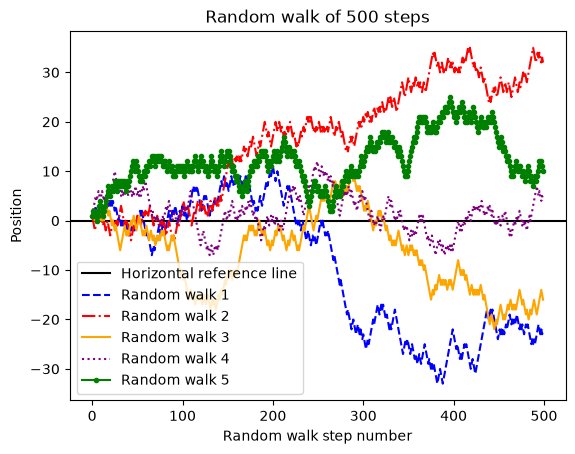

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.axhline(0, color = 'black', label='Horizontal reference line')
ax.plot(positions[0], label='Random walk 1', color='blue', linestyle='--')
ax.plot(positions[1], label='Random walk 2', color='red', linestyle='-.')
ax.plot(positions[2], label='Random walk 3', color='orange', linestyle='-')
ax.plot(positions[3], label='Random walk 4', color='purple', linestyle=':')
ax.plot(positions[4], label='Random walk 5', color='green', linestyle='-', marker='.')

ax.set_xlabel('Random walk step number')  # Add an x-label to the Axes.
ax.set_ylabel('Position')  # Add a y-label to the Axes.
ax.set_title("Random walk of 500 steps")  # Add a title to the Axes.
ax.legend()  # Add a legend.

plt.show()


## 4. Building Subplots in Matplotlib

- Simulate 1,000 random walks of 500 steps each, and compute the final position of each walk
- Create a figure with two subplots side by side:
  - On the left, your plot of 5 random walks from Section 3
  - On the right, a histogram of the 1,000 final positions
- Add a title to each subplot and to the figure with `fig.suptitle()`
- Save your figure as `random_walks.png` with `fig.savefig()`

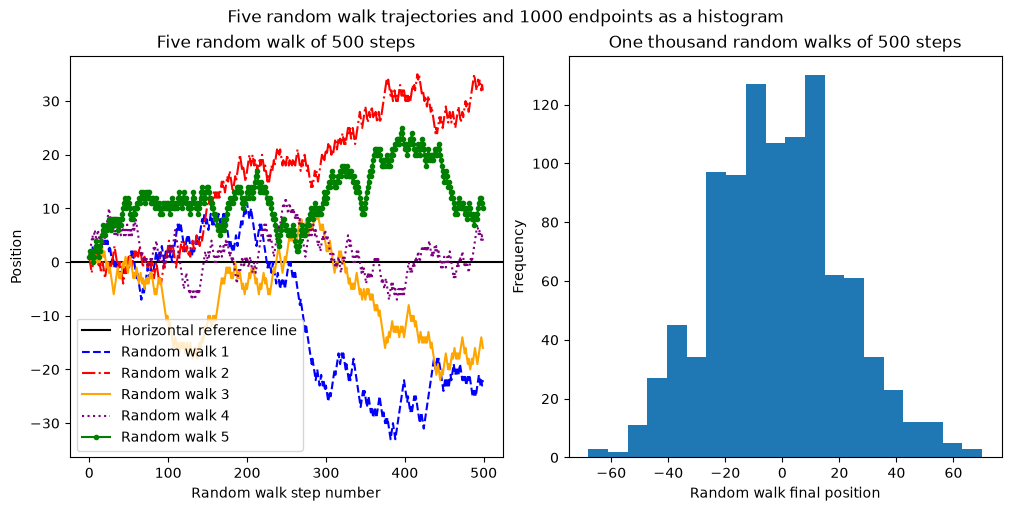

In [43]:
thousand_random_walk = rng.choice([-1, 1], size = (1000,500))
thousand_positions = thousand_random_walk.cumsum(axis = 1)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

ax[0].axhline(0, color = 'black', label='Horizontal reference line')
ax[0].plot(positions[0], label='Random walk 1', color='blue', linestyle='--')
ax[0].plot(positions[1], label='Random walk 2', color='red', linestyle='-.')
ax[0].plot(positions[2], label='Random walk 3', color='orange', linestyle='-')
ax[0].plot(positions[3], label='Random walk 4', color='purple', linestyle=':')
ax[0].plot(positions[4], label='Random walk 5', color='green', linestyle='-', marker='.')

ax[0].set_xlabel('Random walk step number')  # Add an x-label to the Axes.
ax[0].set_ylabel('Position')  # Add a y-label to the Axes.
ax[0].set_title("Five random walk of 500 steps")  # Add a title to the Axes.
ax[0].legend()  # Add a legend.


ax[1].hist(thousand_positions[:,-1], bins=20)

ax[1].set_xlabel('Random walk final position')  # Add an x-label to the Axes.
ax[1].set_ylabel('Frequency')  # Add a y-label to the Axes.
ax[1].set_title("One thousand random walks of 500 steps")  # Add a title to the Axes.
fig.suptitle('Five random walk trajectories and 1000 endpoints as a histogram')

plt.show()

fig.savefig('random_walks.png', dpi=150)

## 5. Save and Push Your Work

On your `assignment-02` branch, stage, commit, and push your notebook and figures:

```bash
git add <your_notebook>.ipynb random_walks.png
git commit -m "Complete Assignment 2"
git push origin assignment-02
```